# Mobile Games A/B Testing

## 1. Description

This dataset comes from a mobile game (Cookie Cats) that tested two different gate placements to understand how early progression affects player engagement. The game randomly assigned new users to one of two versions:
- **Gate 30** – a progression gate placed at level 30
- **Gate 40** – a progression gate placed at level 40

Player behavior was tracked after installation, including total gameplay activity and short-term and long-term retention.
Each user was exposed to only one version of the game, making this a randomized A/B experiment at the user level.

### 1.1 Goal

The goal of this analysis is to determine whether moving the progression gate from level 30 to level 40 improves player engagement and retention.
The business objective is to understand whether delaying the gate increases total gameplay without harming player retention.

### 1.2 Target metric

The analysis focuses on three primary metrics:

- **Total gameplay** activity     
   Measured by sum_gamerounds per user
- **Day-1 retention**     
   Binary indicator of whether a player returned one day after installation
- **Day-7 retention**      
   Binary indicator of whether a player returned seven days after installation
Each user (userid) is treated as an independent experimental unit.

### 1.3 Calculations

To evaluate how gate placement affects player behavior, I analyze gameplay and retention outcomes using statistical methods appropriate for A/B testing.

Each user (userid) serves as an independent experimental unit, since players are randomly assigned to one game version (Gate 30 or Gate 40). For each version, I summarize total gameplay activity (sum_gamerounds) by computing descriptive statistics such as the mean, median, and variability to understand overall engagement patterns.

Exploratory analysis shows that gameplay data is highly right-skewed and contains extreme outliers. As a result, standard parametric assumptions such as normality and equal variances are violated. Therefore, classical two-sample t-tests are not appropriate for comparing gameplay between versions.

Instead, group-level differences in gameplay are evaluated using:

- **Mann–Whitney U** test to compare the distributions of total gameplay between Gate 30 and Gate 40
- **Bootstrap resampling** to estimate confidence intervals for:
   - Mean gameplay per version
   - The difference in mean gameplay between versions

Bootstrap confidence intervals are computed at both 95% and 99% confidence levels, providing robust inference without relying on distributional assumptions.

For retention metrics (Day-1 and Day-7), outcomes are binary. Retention rates are summarized as proportions by version and compared using two-sample proportion tests. Effect sizes are reported as absolute differences in retention rates, accompanied by confidence intervals, allowing assessment of both statistical and practical significance.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import cookiecatplots as ccp

from scipy import stats
from scipy.stats import (
    mannwhitneyu,
    chisquare,
    chi2_contingency, 
    shapiro,
)
from statsmodels.stats.proportion import proportions_ztest

import warnings
warnings.filterwarnings("ignore")

## 2. Load Data

In [2]:
df = pd.read_csv("cookie_cats.csv")
df.head()

,userid,version,sum_gamerounds,retention_1,retention_7
0,116,gate_30,3,False,False
1,337,gate_30,38,True,False
2,377,gate_40,165,True,False
3,483,gate_40,1,False,False
4,488,gate_40,179,True,True


In [3]:
print("\nMissing Values:")
df.isnull().sum()


Missing Values:


userid            0
version           0
sum_gamerounds    0
retention_1       0
retention_7       0
dtype: int64

In [4]:
df['userid'].duplicated()

0        False
1        False
2        False
3        False
4        False
         ...  
90184    False
90185    False
90186    False
90187    False
90188    False
Name: userid, Length: 90189, dtype: bool

### 2.1 Data Overview & Basic Stats

In [5]:
print(df.info())
print(df.describe())
print(df['version'].value_counts())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90189 entries, 0 to 90188
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   userid          90189 non-null  int64 
 1   version         90189 non-null  object
 2   sum_gamerounds  90189 non-null  int64 
 3   retention_1     90189 non-null  bool  
 4   retention_7     90189 non-null  bool  
dtypes: bool(2), int64(2), object(1)
memory usage: 2.2+ MB
None
             userid  sum_gamerounds
count  9.018900e+04    90189.000000
mean   4.998412e+06       51.872457
std    2.883286e+06      195.050858
min    1.160000e+02        0.000000
25%    2.512230e+06        5.000000
50%    4.995815e+06       16.000000
75%    7.496452e+06       51.000000
max    9.999861e+06    49854.000000
version
gate_40    45489
gate_30    44700
Name: count, dtype: int64


In [6]:
df.groupby('version')['sum_gamerounds'].agg(["count", "median", "mean", "std", "max"])

,count,median,mean,std,max
version,,,,,
gate_30,44700,17.0,52.456264,256.716423,49854
gate_40,45489,16.0,51.298776,103.294416,2640


The median is significantly smaller than the mean for both versions (17 vs 52.46 for gate_30 and 16 vs 51.30 for gate_40), suggesting that the data is **right-skewed**.

In [7]:
table1 = pd.crosstab(df["version"], df["retention_1"])
table2 = pd.crosstab(df["version"], df["retention_7"])

print("Retention 1-day:")
print(table1)

print("\nRetention 7-day:")
print(table2)

Retention 1-day:
retention_1  False  True 
version                  
gate_30      24666  20034
gate_40      25370  20119

Retention 7-day:
retention_7  False  True 
version                  
gate_30      36198   8502
gate_40      37210   8279


In [8]:
df["retention_1"] = df["retention_1"].astype(int)
df["retention_7"] = df["retention_7"].astype(int)

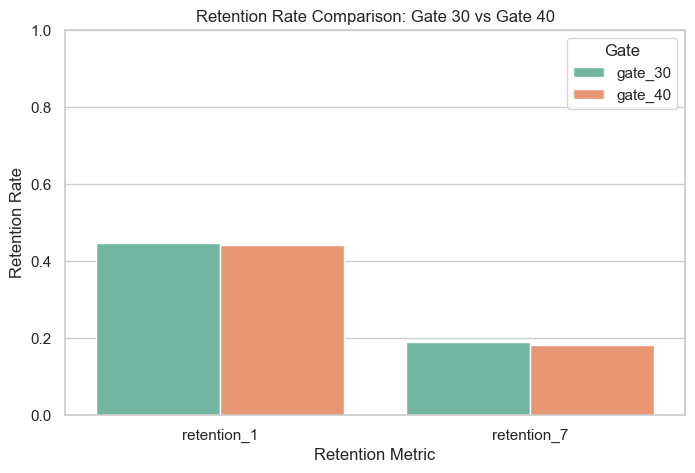

In [9]:
ccp.plot_retention_rates(df)

**Retention_1** appears slightly **higher** for the **gate_30 group**, suggesting that placing the progression gate earlier may help keep new players engaged the next day.
**Retention_7** follows the **same pattern**, although both rates are lower overall, which is typical for mobile games.
Overall, gate_30 demonstrates slightly better performance in both short-term (Day-1) and longer-term (Day-7) retention.

### 2.2 Outlier Analysis & Distribution Shape

Before selecting statistical tests, we examine whether the gameplay metric (sum_gamerounds) contains unusual or extreme values that could violate normality assumptions or disproportionately influence mean-based comparisons.

#### 2.2.1 Distribution by Retention Status and Version

To understand how gameplay varies by user engagement, we first visualize total game rounds split by retention outcomes and experiment version.

**1-Day Retention**

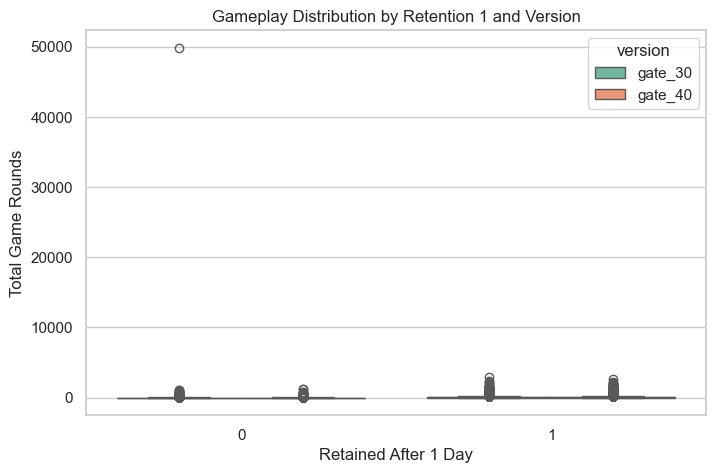

In [10]:
ccp.plot_gameplay_by_retention_outliers(df, retention_col="retention_1")

**7-Day Retention**

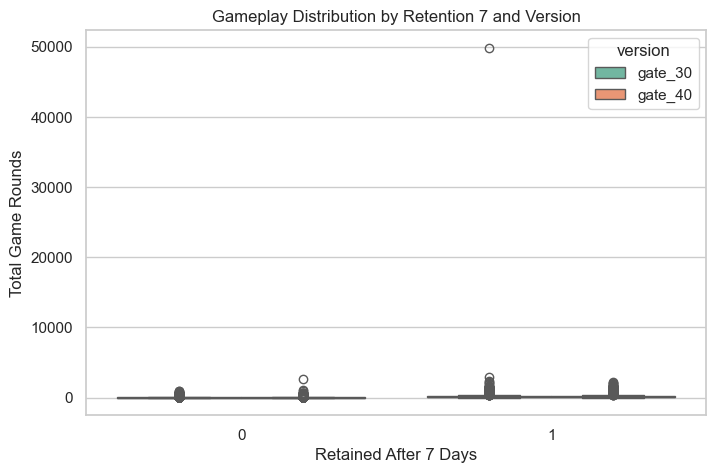

In [11]:
ccp.plot_gameplay_by_retention_outliers(df, retention_col="retention_7")

**Key Observations**

- Retained users exhibit substantially higher gameplay than non-retained users
- Extremely high values are present across both versions
- Outliers are visible regardless of retention window, indicating heavy right skew

#### 2.2.2 Statistical Identification of Extreme Outliers

To formally define extreme gameplay values, we apply the interquartile range (IQR) rule using a conservative threshold (3 × IQR).

In [12]:
q1 = df["sum_gamerounds"].quantile(0.25)
q3 = df["sum_gamerounds"].quantile(0.75)
iqr = q3 - q1

upper_bound = q3 + 3 * iqr
outliers = df[df["sum_gamerounds"] > upper_bound]

- Values above 189 total rounds are classified as statistical outliers
- These users represent ~6% of the population

**Summary Statistics**

In [13]:
outliers.describe()

,userid,sum_gamerounds,retention_1,retention_7
count,5.704000e+03,5704.000000,5704.000000,5704.000000
mean,4.989711e+06,365.569951,0.933029,0.839762
std,2.885169e+06,688.285101,0.249993,0.366859
min,2.218000e+03,190.000000,0.000000,0.000000
25%,2.525356e+06,228.000000,1.000000,1.000000
50%,4.969053e+06,291.000000,1.000000,1.000000
75%,7.499782e+06,405.000000,1.000000,1.000000
max,9.995412e+06,49854.000000,1.000000,1.000000


- Median outlier gameplay ≈ **291 rounds**
- Maximum value ≈ **49,854 rounds**
- Extreme users play **orders of magnitude more** than typical players

**Most Extreme Users**

In [14]:
outliers.sort_values("sum_gamerounds", ascending=False).head(10)

,userid,version,sum_gamerounds,retention_1,retention_7
57702,6390605,gate_30,49854,0,1
7912,871500,gate_30,2961,1,1
29417,3271615,gate_40,2640,1,0
43671,4832608,gate_30,2438,1,1
48188,5346171,gate_40,2294,1,1
46344,5133952,gate_30,2251,1,1
87007,9640085,gate_30,2156,1,1
36933,4090246,gate_40,2124,1,1
88328,9791599,gate_40,2063,1,1
6536,725080,gate_40,2015,1,1


- Are present in both Gate 30 and Gate 40
- Are almost always retained at Day 1
- Often retained at Day 7, though not universally

**Outlier Balance Across Versions**

In [15]:
pd.crosstab(outliers["retention_7"], outliers["version"])

version,gate_30,gate_40
retention_7,,
0,458,456
1,2388,2402


Extreme users are evenly distributed between versions, indicating no version-specific bias caused by outliers.

#### 2.2.4 Log-Scale Visualization of Full Distribution

To visualize both typical players and extreme values simultaneously, we use a logarithmic scale.

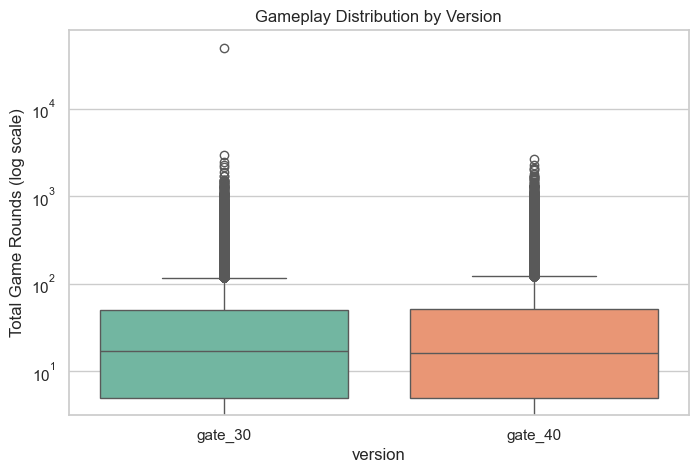

In [16]:
ccp.plot_gameplay_distribution(df, log_scale=True)

**What this shows clearly**
- The bulk of players cluster below ~100 rounds
- A long right tail spans multiple orders of magnitude
- Median gameplay is similar across versions
- Normality assumptions are clearly violated

#### 2.2.5 Analytical Implications

- The gameplay distribution is extremely right-skewed
- A small group of highly engaged players strongly influences the mean
- Removing these users would discard meaningful behavioral data

Therefore:
- Parametric t-tests are inappropriate
- Non-parametric tests and bootstrap methods are required

## 3. Performing A/B Testing

### 3.1 Population by percentage

In [17]:
total_users = len(df)

population_summary = (
    df["version"]
    .value_counts()
    .rename("count")
    .to_frame()
)

population_summary["proportion"] = population_summary["count"] / total_users
population_summary["percentage"] = population_summary["proportion"] * 100

population_summary

,count,proportion,percentage
version,,,
gate_40,45489,0.504374,50.437415
gate_30,44700,0.495626,49.562585


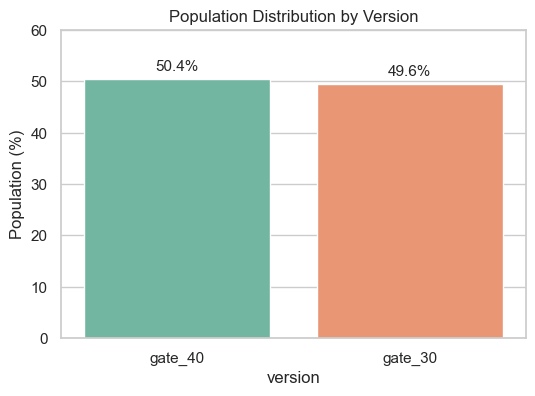

In [18]:
ccp.plot_population_distribution(population_summary)

### 3.2 Sample Ratio Mismatch (SRM) check

Sample Ratio Mismatch (SRM) checks whether users were split into variants as intended.
- **H₀ (null):** Users are split according to the expected ratio
- **H₁:** The split deviates from the expected ratio

In [19]:
monitored = df["version"].value_counts().sort_index()
monitored

version
gate_30    44700
gate_40    45489
Name: count, dtype: int64

In [20]:
total_users = monitored.sum()
expected = [total_users / 2, total_users / 2]
expected

[np.float64(45094.5), np.float64(45094.5)]

In [21]:
chi2, p_value = chisquare(f_obs=monitored, f_exp=expected)
chi2, p_value

(np.float64(6.9024049496058275), np.float64(0.008607987810836262))

✔️ Chi-square statistic = 6.902   
✔️ p-value = 0.0086

A statistically significant SRM was detected (p = 0.0086).  
Although the absolute imbalance is small (~0.9%), the large sample size makes this deviation detectable.     
Results should therefore be interpreted cautiously, as SRM may indicate imperfect randomization or logging effects.    

### 3.3 Compute version mean per retention

Within each version, how does engagement differ between retained and non-retained users?

In [22]:
comp_retent1 = df.groupby(["version", "retention_1"])["sum_gamerounds"].mean()
comp_retent7 = df.groupby(["version", "retention_7"])["sum_gamerounds"].mean()

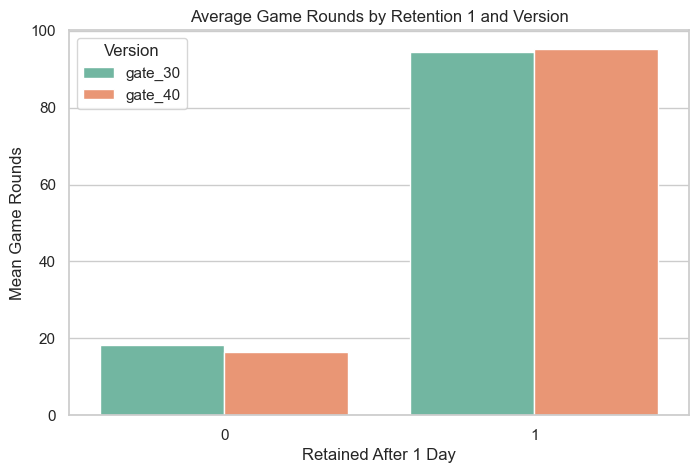

In [23]:
ccp.plot_mean_gameplay_by_retention(df, retention_col="retention_1")

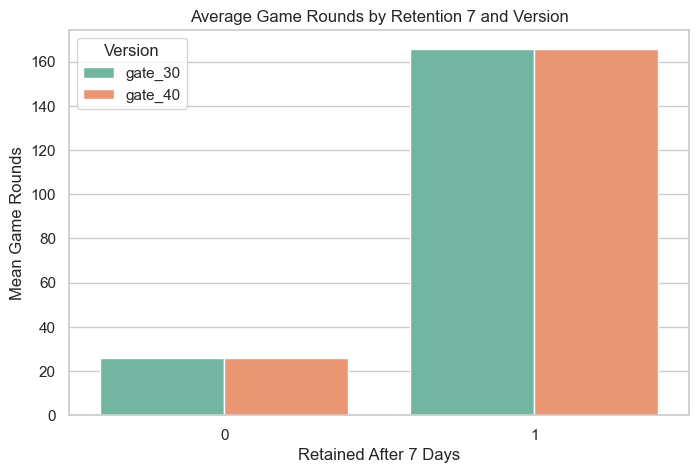

In [24]:
ccp.plot_mean_gameplay_by_retention(df, retention_col="retention_7")

While retention is the primary outcome metric, we additionally examine average gameplay engagement (sum_gamerounds) conditional on retention status.
This exploratory analysis helps contextualize observed retention differences but is not used for causal inference.

### 3.4 Mann–Whitney U test for pairwise comparisons between versions

- **Null hypothesis (H₀):** The distributions of sum_gamerounds are the same for gate_30 and gate_40.
- **Alternative hypothesis (H₁):** The distributions are different.

In [36]:
g30 = df[df["version"] == "gate_30"]["sum_gamerounds"]
g40 = df[df["version"] == "gate_40"]["sum_gamerounds"]

In [39]:
g30_vals = g30.astype(int).to_numpy()
g40_vals = g40.astype(int).to_numpy()

u_stat, p_val = mannwhitneyu(g30_vals, g40_vals, alternative="two-sided")

In [40]:
u_stat, p_val

(np.float64(1024331250.5), np.float64(0.05020880772044255))

No statistically significant difference in gameplay was detected
(Mann–Whitney U p ≈ 0.05).

### 3.5 Bootstrap Confidence Intervals

Bootstrap confidence intervals confirm the non-parametric test results.   
Bootstrap methods were used due to non-normal, skewed sales distributions.

If p-value < 0.05 → Reject H₀ (there is a significant difference).
If p-value > 0.05 → Fail to reject H₀ (no significant difference).

In [27]:
def bootstrap_ci(data, n_boot=5000, ci=0.95):
    boot_means = []
    for _ in range(n_boot):
        sample = data.sample(frac=1, replace=True)
        boot_means.append(sample.mean())

    lower = np.percentile(boot_means, (1-ci)/2 * 100)
    upper = np.percentile(boot_means, (1+ci)/2 * 100)
    return np.array(boot_means), lower, upper


In [28]:
boot30_95, low30_95, high30_95 = bootstrap_ci(g30, ci=0.95)
boot40_95, low40_95, high40_95 = bootstrap_ci(g40, ci=0.95)

print("Gate 30 — 95% CI:", low30_95, high30_95)
print("Gate 40 — 95% CI:", low40_95, high40_95)

Gate 30 — 95% CI: 50.60381823266219 55.1273769574944
Gate 40 — 95% CI: 50.33525028028754 52.235195321945966


In [29]:
boot_diff = boot30_95 - boot40_95

diff_mean = boot_diff.mean()
diff_low = np.percentile(boot_diff, 2.5)
diff_high = np.percentile(boot_diff, 97.5)

In [30]:
print("Mean difference (Gate30 - Gate40):", diff_mean)
print("95% CI for difference:", diff_low, diff_high)

Mean difference (Gate30 - Gate40): 1.142394317575412
95% CI for difference: -0.9583305066672201 3.997490952381581


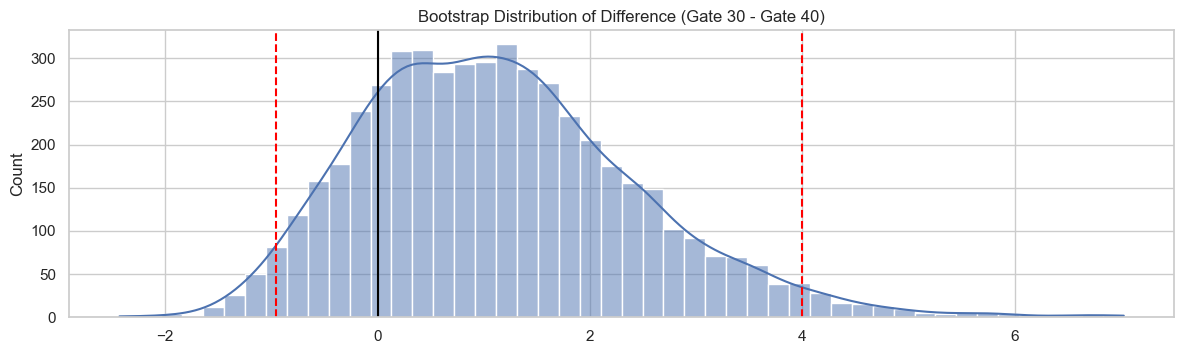

In [31]:
plt.figure(figsize=(12,10))

plt.subplot(3,1,3)
sns.histplot(boot_diff, kde=True)
plt.title("Bootstrap Distribution of Difference (Gate 30 - Gate 40)")
plt.axvline(0, color='black')
plt.axvline(diff_low, color='red', linestyle='--')
plt.axvline(diff_high, color='red', linestyle='--')

plt.tight_layout()
plt.show()

The 95% bootstrap CI includes zero → no meaningful difference.

### 3.6 Retention Test (Two-proportion z-test + Effect Size + Analytical CI)

**Prepare groups**

In [32]:
g30 = df[df["version"] == "gate_30"]
g40 = df[df["version"] == "gate_40"]

count = np.array([
    g30["retention_7"].sum(),
    g40["retention_7"].sum()
])

nobs = np.array([
    len(g30),
    len(g40)
])

**Two-proportion z-test**

In [33]:
z_stat, p_val = proportions_ztest(count, nobs)
diff = g30["retention_7"].mean() - g40["retention_7"].mean()

print("Z-statistic:", z_stat)
print("P-value:", p_val)
print("Difference in retention (Gate30 - Gate40):", diff)

Z-statistic: 3.164358912748191
P-value: 0.001554249975614329
Difference in retention (Gate30 - Gate40): 0.008201298315205913


A statistically significant difference in Day-7 retention is detected (p < 0.05), but the absolute effect size (~0.8%) is very small, so the difference is unlikely to be practically meaningful.

**Analytical 95% Confidence Interval**

In [34]:
p30 = g30["retention_7"].mean()
p40 = g40["retention_7"].mean()
n30 = len(g30)
n40 = len(g40)

diff = p30 - p40

se = np.sqrt((p30*(1-p30)/n30) + (p40*(1-p40)/n40))

z = 1.96
ci_lower = diff - z * se
ci_upper = diff + z * se

print("95% CI for difference:", ci_lower, "to", ci_upper)

95% CI for difference: 0.003120950858949586 to 0.01328164577146224


The analytical confidence interval confirms the effect is statistically significant but very small (~0.3% to 1.3%), supporting the conclusion that Gate 30 and Gate 40 are practically equivalent in Day-7 retention.

## 4. Decision

The A/B test provides no evidence that moving the progression gate from level 30 to level 40 improves player engagement or retention.

Total gameplay shows no statistically or practically meaningful difference between versions.
Day-1 retention does not differ significantly.
Day-7 retention shows a statistically significant difference, but the effect size (~0.8%) is negligible in practice.

Given the absence of meaningful improvements and the presence of a small sample ratio mismatch, the recommended decision is to retain the current Gate 30 configuration.